# 🏈 QB Scouting Report Analyzer
Extracts and categorizes positive/negative quarterback traits from the `scouting_report` column in your CSV.

**Workflow:** Run all cells top to bottom. Results are saved to CSV and visualized inline.

## 1. Install & Import Dependencies

In [1]:
import subprocess, sys
pkgs = ["transformers", "torch", "pandas", "matplotlib", "seaborn", "tqdm"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ Dependencies ready")

✅ Dependencies ready


In [2]:
import re, warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from transformers import pipeline

warnings.filterwarnings('ignore')
print("✅ Imports complete")

✅ Imports complete


## 2. Configuration

In [5]:
# ── PATH TO YOUR CSV ──────────────────────────────────────────────
CSV_PATH = "C:/Users/austy/gAItor-Football/Data/cleaned_recruits_data.csv"   # update if needed
NAME_COL = "name"                        # column with player name
REPORT_COL = "scouting_report"           # column with report text

# ── QB TRAIT CATEGORIES ───────────────────────────────────────────
# Each category has keywords used to detect relevant sentences.
# Extend freely.
TRAIT_CATEGORIES = {
    "Arm Strength": [
        "arm strength", "velocity", "zip", "rocket", "cannon", "deep ball",
        "throws hard", "weak arm", "arm talent", "arm power", "touch",
        "loft", "trajectory", "rifle", "drive the ball"
    ],
    "Accuracy": [
        "accuracy", "accurate", "precision", "on-target", "off-target",
        "completion", "inaccurate", "placement", "inconsistent throws",
        "footwork", "mechanics", "throwing motion", "release", "high throws",
        "low throws", "sail", "ball speed"
    ],
    "Decision Making": [
        "decision", "reads", "pre-snap", "post-snap", "progression",
        "turnover", "interception", "fumble", "protect the ball",
        "quick trigger", "locks on", "stares down", "check down",
        "hot route", "audible", "coverage", "identifies"
    ],
    "Mobility & Athleticism": [
        "mobility", "mobile", "athletic", "scramble", "escapability",
        "speed", "dual-threat", "run threat", "elusive", "run",
        "extension plays", "chunk runs", "athlete"
    ],
    "Pocket Presence": [
        "pocket", "pressure", "step up", "navigate", "uncomfortable",
        "collapses", "happy feet", "statue", "anchors", "buys time",
        "off-platform", "unconventional", "sack"
    ],
    "Football IQ": [
        "football IQ", "smart", "intelligent", "understand", "scheme",
        "recognition", "anticipation", "anticipates", "diagnose",
        "protection", "blitz", "line calls", "adjustments",
        "reads defenses", "vision"
    ],
    "Leadership & Intangibles": [
        "leader", "leadership", "composure", "poise", "competitive",
        "work ethic", "film study", "coachable", "character",
        "locker room", "clutch", "demeanor", "mature", "mental",
        "confidence", "magnetism"
    ],
    "Size & Physical": [
        "size", "height", "weight", "frame", "build", "stature",
        "durability", "injury", "prototype", "undersized", "bulk",
        "slender", "narrow", "mass", "body"
    ],
    "NFL / Draft Projection": [
        "nfl", "draft", "projects", "round", "professional", "next level",
        "franchise", "starter", "upside", "ceiling", "floor"
    ],
}

print(f"📋 Tracking {len(TRAIT_CATEGORIES)} trait categories")

📋 Tracking 9 trait categories


## 3. Load Data

In [6]:
df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.dropna(subset=[REPORT_COL])

print(f"✅ Loaded {len(df_raw)} QBs from '{CSV_PATH}'")
print(f"   Columns available: {df_raw.columns.tolist()}")
df_raw[[NAME_COL, REPORT_COL]].head(3)

✅ Loaded 152 QBs from 'C:/Users/austy/gAItor-Football/Data/cleaned_recruits_data.csv'
   Columns available: ['name', 'url', 'rank', 'height', 'weight', 'composite_rating', 'school_info', 'city', 'state', 'scouting_report', 'draft_projection', 'reminds_of', 'evaluated_date', 'analyst', 'athletic_background', 'committed_school', 'numerical_rating', 'Is_FBS', 'Is_SEC', 'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB', 'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked', 'Is_From_East', 'Is_From_West', 'weight_to_height_ratio', 'bmi']


,name,scouting_report
0,Spencer Rattler,Slightly built prospect with narrow shoulders....
1,Jayden Daniels,Possesses a naturally slender build and frame....
2,Bo Nix,Big enough quarterback with some stockiness th...


## 4. Sentence Segmentation & Trait Detection

In [7]:
def split_sentences(text: str) -> list:
    raw = re.split(r'(?<=[.!?])\s+', text.replace("\n", " "))
    return [s.strip() for s in raw if len(s.strip()) > 20]

def detect_categories(sentence: str) -> list:
    sl = sentence.lower()
    return [cat for cat, kws in TRAIT_CATEGORIES.items()
            if any(kw.lower() in sl for kw in kws)]

records = []
for _, row in df_raw.iterrows():
    player = row[NAME_COL]
    for sent in split_sentences(str(row[REPORT_COL])):
        cats = detect_categories(sent)
        if cats:
            records.append({"player": player, "sentence": sent, "categories": cats})

df_sents = pd.DataFrame(records)
print(f"✅ {len(df_sents)} trait-relevant sentences across {df_sents['player'].nunique()} QBs")
df_sents.head(4)

✅ 1297 trait-relevant sentences across 152 QBs


,player,sentence,categories
0,Spencer Rattler,Slightly built prospect with narrow shoulders.,[Size & Physical]
1,Spencer Rattler,Limited physical upside.,[NFL / Draft Projection]
2,Spencer Rattler,Natural passer with a quick release.,[Accuracy]
3,Spencer Rattler,Does not need to load up to generate velocity.,[Arm Strength]


## 5. Sentiment Scoring

In [8]:
print("⏳ Loading sentiment model...")
sent_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True, max_length=512,
)
print("✅ Model ready")

⏳ Loading sentiment model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model ready


In [9]:
texts = df_sents["sentence"].tolist()
preds = []
BATCH = 32
for i in tqdm(range(0, len(texts), BATCH), desc="Scoring"):
    preds.extend(sent_pipe(texts[i:i+BATCH]))

df_sents["sentiment"] = [p["label"] for p in preds]
df_sents["score"] = [
    p["score"] if p["label"] == "POSITIVE" else -p["score"]
    for p in preds
]

# Explode so each category gets its own row
df_exp = df_sents.explode("categories").rename(columns={"categories": "category"})

print(f"\n✅ Done  |  POSITIVE: {(df_sents.sentiment=='POSITIVE').sum()}  |  NEGATIVE: {(df_sents.sentiment=='NEGATIVE').sum()}")
df_sents[["player","sentence","sentiment","score"]].head(5)

Scoring: 100%|██████████| 41/41 [00:29<00:00,  1.38it/s]


✅ Done  |  POSITIVE: 1028  |  NEGATIVE: 269


,player,sentence,sentiment,score
0,Spencer Rattler,Slightly built prospect with narrow shoulders.,NEGATIVE,-0.911064
1,Spencer Rattler,Limited physical upside.,NEGATIVE,-0.996830
2,Spencer Rattler,Natural passer with a quick release.,POSITIVE,0.996002
3,Spencer Rattler,Does not need to load up to generate velocity.,POSITIVE,0.985321
4,Spencer Rattler,Throws with more zip than power.,NEGATIVE,-0.929181


## 6. Per-Player Trait Summary Table

In [10]:
summary = (
    df_exp.groupby(["player", "category", "sentiment"])
    .agg(count=("sentence", "count"), avg_score=("score", "mean"))
    .reset_index()
)

pivot = summary.pivot_table(
    index=["player", "category"], columns="sentiment",
    values="count", fill_value=0
).reset_index()

cat_scores = (
    df_exp.groupby(["player", "category"])["score"]
    .mean().reset_index().rename(columns={"score": "mean_score"})
)
pivot = pivot.merge(cat_scores, on=["player", "category"])
pivot["mean_score"] = pivot["mean_score"].round(3)
for col in ["POSITIVE", "NEGATIVE"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot.sort_values(["player", "mean_score"], ascending=[True, False])
print("📊 Trait Summary — scroll right to see all columns")
pivot.style.background_gradient(subset=["mean_score"], cmap="RdYlGn", vmin=-1, vmax=1)

📊 Trait Summary — scroll right to see all columns


,player,category,NEGATIVE,POSITIVE,mean_score
0,AJ Duffy,Accuracy,0.000000,1.000000,0.999000
4,AJ Duffy,Pocket Presence,0.000000,1.000000,0.999000
2,AJ Duffy,Decision Making,0.000000,2.000000,0.964000
3,AJ Duffy,Mobility & Athleticism,0.000000,1.000000,0.938000
1,AJ Duffy,Arm Strength,0.000000,1.000000,0.929000
5,AJ Swann,Accuracy,0.000000,1.000000,0.999000
7,AJ Swann,Decision Making,0.000000,1.000000,0.999000
8,AJ Swann,NFL / Draft Projection,0.000000,1.000000,0.999000
9,AJ Swann,Pocket Presence,0.000000,2.000000,0.995000
10,AJ Swann,Size & Physical,0.000000,1.000000,0.995000


## 7. Top Positive & Negative Trait Sentences per Player

In [11]:
# ── Configure which players to print ─────────────────────────────
# Set to None to print ALL players, or pass a list e.g.:
#   PLAYERS_TO_SHOW = ["Spencer Rattler", "Jayden Daniels"]
PLAYERS_TO_SHOW = None   # ← change here
TOP_N = 5                # sentences per sentiment per player
# ─────────────────────────────────────────────────────────────────

players = df_sents["player"].unique() if PLAYERS_TO_SHOW is None else PLAYERS_TO_SHOW

for player in players:
    sub = df_sents[df_sents["player"] == player]
    pos = sub[sub["sentiment"] == "POSITIVE"].nlargest(TOP_N, "score")
    neg = sub[sub["sentiment"] == "NEGATIVE"].nsmallest(TOP_N, "score")

    print(f"{'='*72}")
    print(f"  🏈  {player}")
    print(f"{'='*72}")

    print("  ✅ STRENGTHS")
    for _, r in pos.iterrows():
        cats = ", ".join(r["categories"]) if isinstance(r["categories"], list) else r["categories"]
        print(f"    [{r['score']:+.3f}] [{cats}]")
        print(f"    {r['sentence']}")
        print()

    print("  ❌ CONCERNS")
    for _, r in neg.iterrows():
        cats = ", ".join(r["categories"]) if isinstance(r["categories"], list) else r["categories"]
        print(f"    [{r['score']:+.3f}] [{cats}]")
        print(f"    {r['sentence']}")
        print()
    print()

  🏈  Spencer Rattler
  ✅ STRENGTHS
    [+1.000] [Mobility & Athleticism]
    Fluid athlete with the ability to extend plays.

    [+1.000] [Accuracy]
    Accurate in ball placement.

    [+1.000] [Leadership & Intangibles]
    Has some natural confidence and magnetism as a leader.

    [+0.998] [Pocket Presence]
    Disassociates his upper and lower half to make off-platform, unconventional throws with ease.

    [+0.996] [Accuracy]
    Natural passer with a quick release.

  ❌ CONCERNS
    [-0.998] [Decision Making]
    Can play too loose at times which ticks his interception numbers up some.

    [-0.997] [Size & Physical]
    Body may limit durability.

    [-0.997] [NFL / Draft Projection]
    Limited physical upside.

    [-0.929] [Arm Strength]
    Throws with more zip than power.

    [-0.911] [Size & Physical]
    Slightly built prospect with narrow shoulders.


  🏈  Jayden Daniels
  ✅ STRENGTHS
    [+1.000] [Arm Strength, Accuracy, Mobility & Athleticism]
    Does a nice job o

## 8. Visualizations

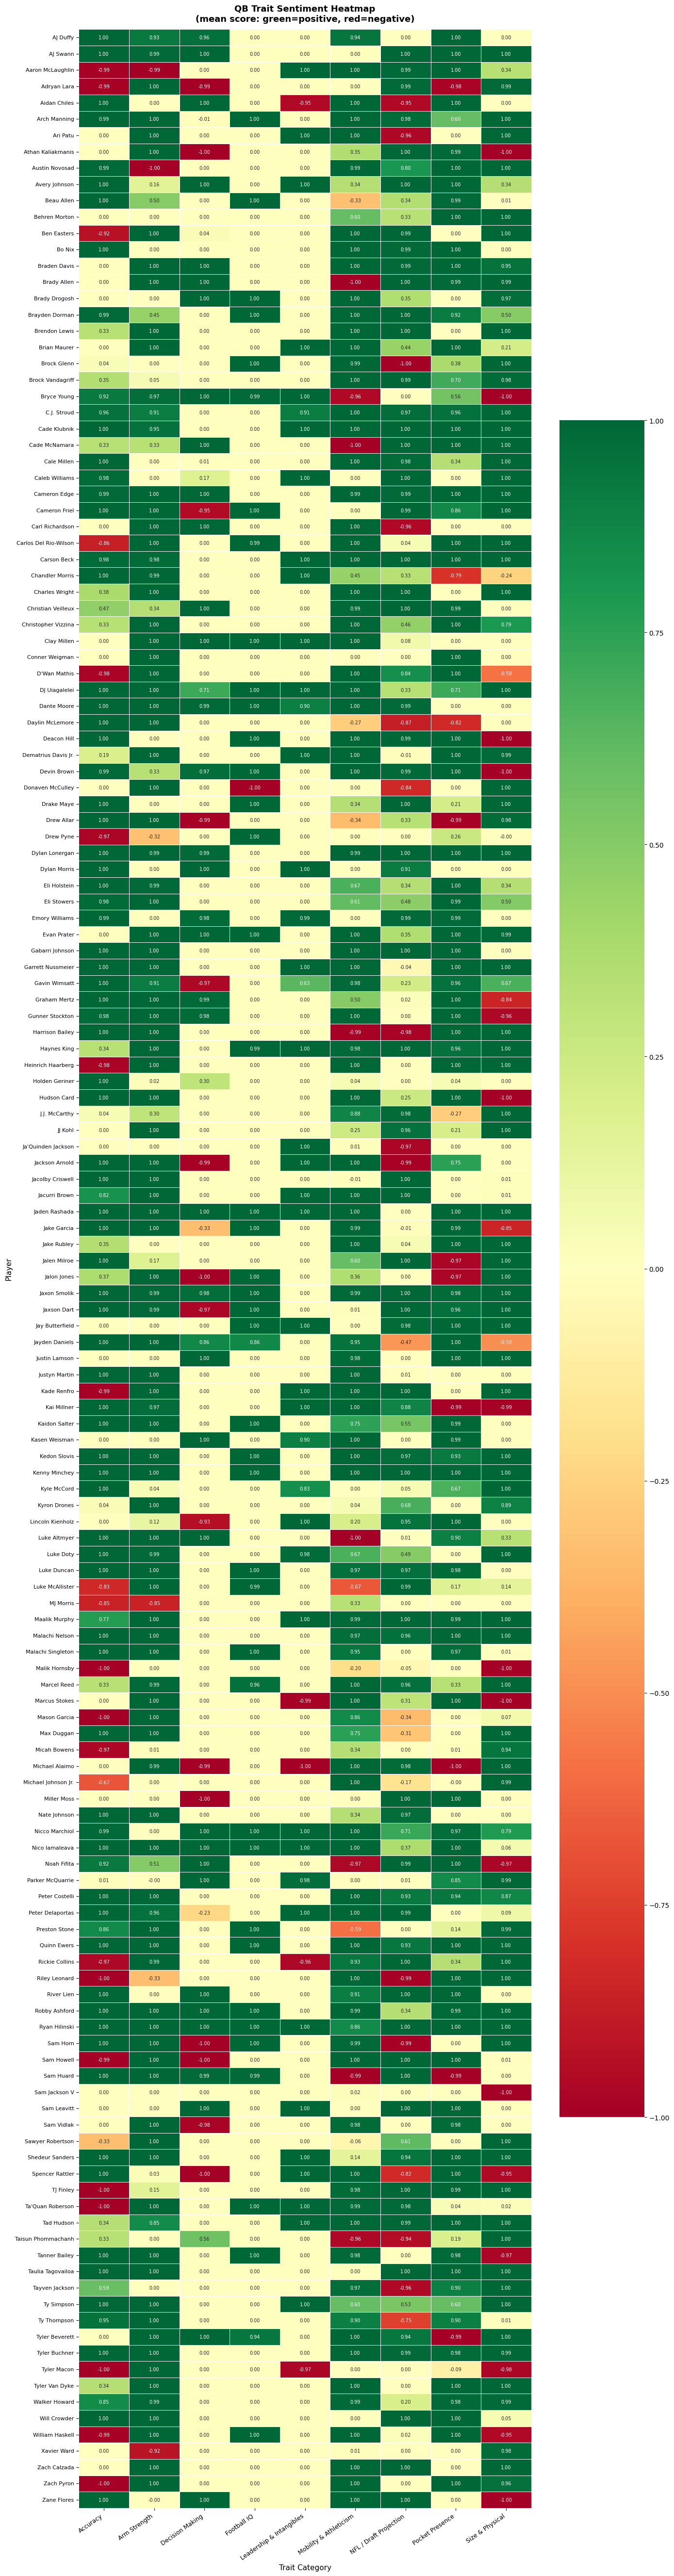

In [12]:
# ── Chart 1: Comparison heatmap — all QBs × all categories ──
heatmap_data = (
    df_exp.groupby(["player", "category"])["score"]
    .mean().unstack(fill_value=0)
)

fig_h = max(8, len(heatmap_data) * 0.35)
fig, ax = plt.subplots(figsize=(14, fig_h))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("QB Trait Sentiment Heatmap\n(mean score: green=positive, red=negative)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Trait Category", fontsize=11)
ax.set_ylabel("Player", fontsize=11)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("qb_heatmap_all.png", dpi=150, bbox_inches="tight")
plt.show()

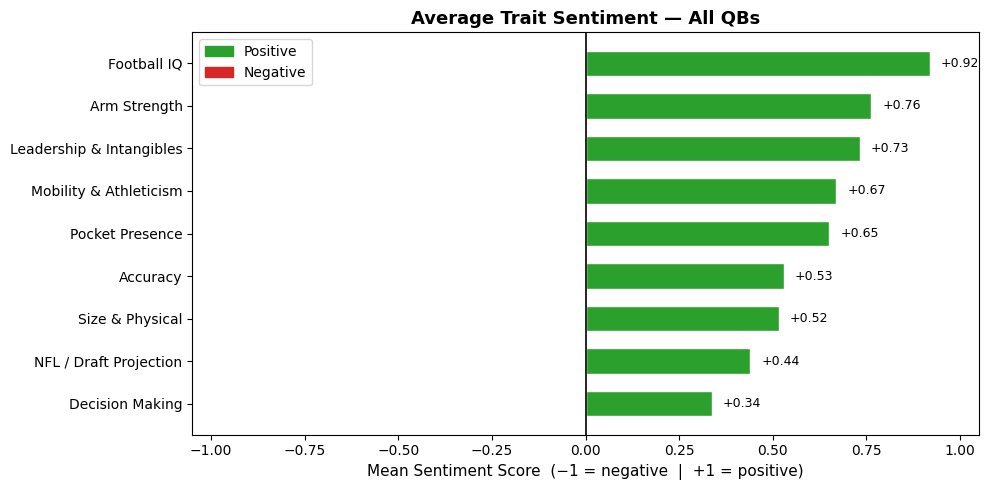

In [13]:
# ── Chart 2: Fleet-wide average sentiment per category ──
fleet_avg = df_exp.groupby("category")["score"].mean().sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in fleet_avg.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(fleet_avg.index, fleet_avg.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Mean Sentiment Score  (−1 = negative  |  +1 = positive)", fontsize=11)
ax.set_title("Average Trait Sentiment — All QBs", fontsize=13, fontweight="bold")
ax.set_xlim(-1.05, 1.05)
for bar, val in zip(bars, fleet_avg.values):
    x = val + (0.03 if val >= 0 else -0.03)
    ax.text(x, bar.get_y() + bar.get_height()/2, f"{val:+.2f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=9)
pos_p = mpatches.Patch(color="#2ca02c", label="Positive")
neg_p = mpatches.Patch(color="#d62728", label="Negative")
ax.legend(handles=[pos_p, neg_p])
plt.tight_layout()
plt.savefig("qb_fleet_avg.png", dpi=150)
plt.show()

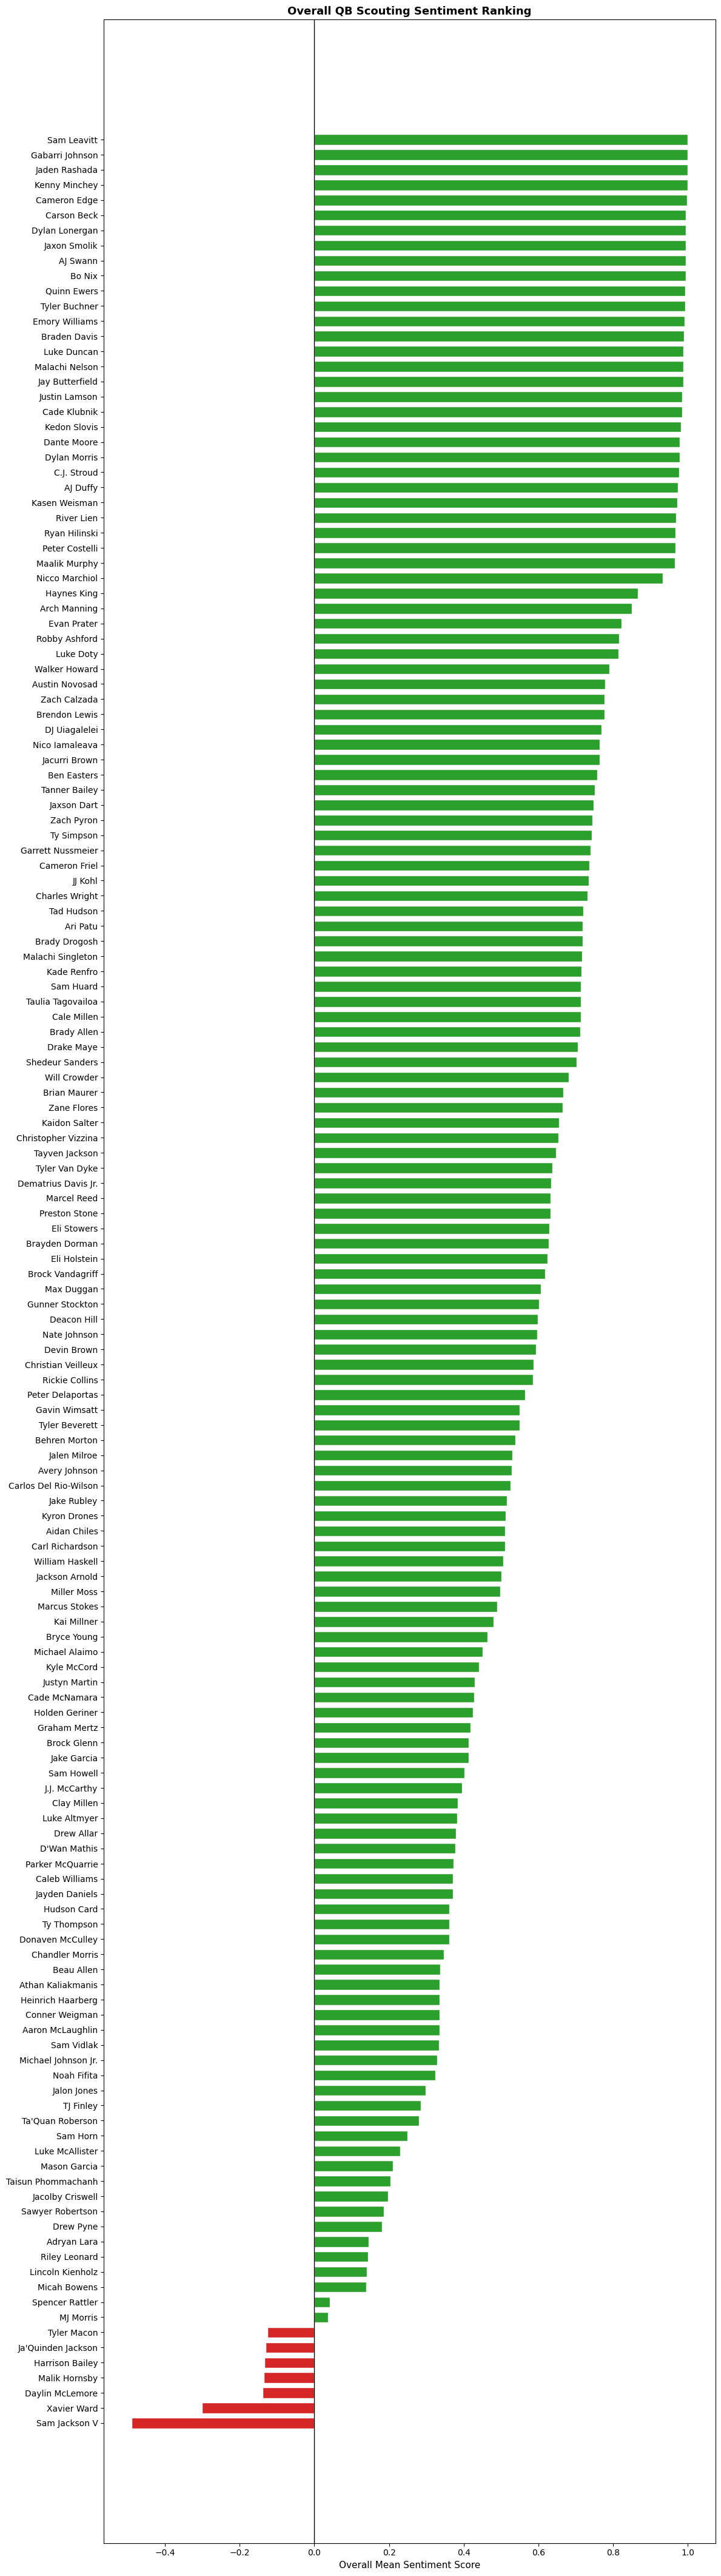

In [14]:
# ── Chart 3: Per-player overall score (bar chart) ──
overall = df_sents.groupby("player")["score"].mean().sort_values(ascending=False)
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in overall.values]

fig, ax = plt.subplots(figsize=(12, max(5, len(overall)*0.28)))
ax.barh(overall.index[::-1], overall.values[::-1], color=colors[::-1], edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Overall Mean Sentiment Score", fontsize=11)
ax.set_title("Overall QB Scouting Sentiment Ranking", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("qb_overall_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export Results

In [15]:
export = df_sents.copy()
export["categories"] = export["categories"].apply(lambda x: "; ".join(x) if isinstance(x, list) else x)
export.to_csv("qb_trait_sentences.csv", index=False)
pivot.to_csv("qb_trait_summary.csv", index=False)
overall.reset_index().rename(columns={"score": "mean_sentiment_score"}).to_csv("qb_overall_scores.csv", index=False)

print("✅ Exported:")
print("   qb_trait_sentences.csv  — every scored sentence with player + categories")
print("   qb_trait_summary.csv    — positive/negative counts & mean score per player × category")
print("   qb_overall_scores.csv   — one overall sentiment score per QB")

✅ Exported:
   qb_trait_sentences.csv  — every scored sentence with player + categories
   qb_trait_summary.csv    — positive/negative counts & mean score per player × category
   qb_overall_scores.csv   — one overall sentiment score per QB
